In [12]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d


We want to find the $k$-dependent eigenvalues of matrix (4.12) in the Overleaf. If, for a given temperature $\beta$, all eigenvalues for all $k$ are negative, the uniform distribution is stable (no clustering).
The matrix depends on pairwise interaction potential $W$ (rather its Fourier transform). We consider the Gaussian case.

For the wrapped Gaussian defined on $[-L/2,L/2]$ we have that $$W(r) = \sum^{\infty}_{n=-\infty}\exp{\left(-\frac{\left(r+Ln\right)^{2}}{2\sigma^{2}}\right)}$$
and therefore taking the Fourier transform we have for $k$ of the form $2\pi z/L$, where $z \in \mathbb{Z}$
$$\hat{W}(k) = \int^{L/2}_{-L/2} W(r) e^{-ik r}dr = \sum^{\infty}_{n=-\infty}\int^{L/2}_{-L/2} \exp{\left(-\frac{\left(r+Ln\right)^{2}}{2\sigma^{2}}-ikr\right)}dr$$
$$ = \sum^{\infty}_{n=-\infty}\int^{L/2}_{-L/2} \exp{\left(-\frac{\left(r+Ln\right)^{2}}{2\sigma^{2}}\right)}\left(\cos{(kr)} - i\sin{(kr)}\right)dr $$
$$= \sum^{\infty}_{n=-\infty}\int^{L/2}_{-L/2} \exp{\left(-\frac{\left(r+Ln\right)^{2}}{2\sigma^{2}}\right)}\cos{(kr)}dr$$
$$= \int^{\infty}_{-\infty} \exp{\left(-\frac{r^{2}}{2\sigma^{2}}\right)}\cos{\left(\frac{2\pi z r}{L}\right)}dr$$
$$= -\sqrt{2\pi \sigma^2}e^{-2\sigma^{2}\pi^{2}z^{2}/L^{2}} = -\sqrt{2\pi \sigma^2} e^{-\sigma^{2}k^{2}/2}.$$

Alternative: Try non-wrapped Gaussian:
$$
\hat{W}(k)=\int_{-\frac{L}{2}}^{\frac{L}{2}} e^{\frac{r^2}{2\sigma^2}}e^{-ikr}dr=...=-\sqrt{\frac{\pi \sigma^2}{2}}e^{-\frac{k^2\sigma^2}{2}}\left[ erf\left( \frac{\frac{L}{2}-ik\sigma^2}{\sqrt{2\sigma^2}} \right) +erf\left( \frac{\frac{L}{2}+ik\sigma^2}{\sqrt{2\sigma^2}} \right) \right] = -\sqrt{2\pi\sigma^2} e^{-\frac{-k^2\sigma^2}{2}}Re\left( erf\left( \frac{\frac{L}{2}+ik\sigma^2}{\sqrt{2\sigma^2}} \right) \right)
$$

In [13]:
#Wrapped Gaussian model
σ = 1.0  # variance
L = 10.0 # boxlength

def W_hat(k):
    W_hat_k = -np.sqrt(2*np.pi)*σ*np.exp(-σ**2 * k**2 /2) #
    return W_hat_k

# non-wrapped case:
#from scipy.special import erf
#def W_hat(k):
#    W_hat_k = -np.sqrt(2*np.pi)*σ * np.exp(-σ**2*k**2/2)*np.real( erf( (0.5*L + 1j*k*σ**2)/(np.sqrt(2*σ**2)) ) )
#    return W_hat_k

# The matrix A. We restrict it to the first "dim" rows.
def matrix(k,β,γ,L,dim):
    A_k = np.zeros(shape=(dim,dim),dtype=np.complex_)
    for i in range(dim-1):
        A_k[i][i] = i*(-γ) 
        A_k[i][i+1] = -k*np.sqrt((i+1)/β)*1j 
        A_k[i+1][i] = -k*np.sqrt((i+1)/β)*1j 
    A_k[dim-1][dim-1] = (dim-1)*-γ
    A_k[1][0] += -k*np.sqrt(β)*1j*W_hat(k)/L 
    return A_k

In [14]:
# print maximum eigenvalue for a bunch of k.
ks = np.arange(0,20)*2*np.pi/L
for k in ks:
    print(np.max(np.real(np.linalg.eigvals(matrix(k, 3, 0.1, L, 30)))))

-0.0
-0.12025810828631915
-0.519939365161351
-0.9194627537478083
-0.9557857146950601
-0.9640210960093532
-0.9659502639100812
-0.9665862452165968
-0.9669289195271471
-0.9671576702459198
-0.9673208310332041
-0.9674414676121457
-0.967533180472793
-0.9676045302421581
-0.9676611289192214
-0.9677067800610677
-0.9677441356783936
-0.9677750906700877
-0.9678010281631655
-0.9678229768611529


In [15]:
k = 2*np.pi/L
beta = 2
gamma = 0.5
dim = 20

A = matrix(k, beta, gamma, L, dim)
np.max(np.real(np.linalg.eigvals(A)))


-0.17605847948476003

In [16]:
# For a number of temperatures and friction values, obtain largest eigenvalues.
def function():
    N_β = 200    # Number of temperature points.
    N_γ = 10      # Number of friction points.
    β_list = np.linspace(1,20,N_β)
    γ_list = np.linspace(0.0,1,N_γ) #np.logspace(-8.0, 1.0, num=N_γ)
    
    spectral_radius = np.zeros((N_β,N_γ))  # store largest real part of eigenvalues here.
    
    k_max = 50  # number of wavenumbers to test.
    
    approximation_dimension = 40  # number of matrix rows to consider.
    
    # for all beta and gamma...
    for i in range(len(β_list)):
        print("beta: ", i)
        β = β_list[i]
        for j in range(len(γ_list)):
            γ = γ_list[j]
            
            maximum = np.max(np.real(np.linalg.eigvals(matrix(0.,β,γ,L,approximation_dimension))))
            
            # find maximum eigenvalue for all wavenumbers
            for k in range(k_max - 1):
                #change to maximum real part
                partial_max = np.max(np.real(np.linalg.eigvals(matrix(2*np.pi*(k+1)/L,β,γ,L,approximation_dimension))))
                #print(partial_max,maximum)
                if partial_max > maximum:
                    maximum = partial_max
                partial_max = np.max(np.real(np.linalg.eigvals(matrix(-2*np.pi*(k+1)/L,β,γ,L,approximation_dimension))))
                #print(partial_max,maximum)
                if partial_max > maximum:
                    maximum = partial_max
            spectral_radius[i,j] = maximum
    
    return β_list,γ_list,spectral_radius


# $(2\pi)^{1/2} * \sigma \frac{N}{2L} \kappa$ in 1D

In [17]:
# Print critical beta given by literature.
print('Theoretical critcal beta = ',1/((σ**2)*np.sqrt(2*np.pi)/(L)))

Theoretical critcal beta =  3.989422804014327


In [18]:
# For all temperatures and frictions, obtain largest eigenvalues.
β_list,γ_list,spectral_radius = function()

beta:  0
beta:  1
beta:  2
beta:  3
beta:  4
beta:  5
beta:  6
beta:  7
beta:  8
beta:  9
beta:  10
beta:  11
beta:  12
beta:  13
beta:  14
beta:  15
beta:  16
beta:  17
beta:  18
beta:  19
beta:  20
beta:  21
beta:  22
beta:  23
beta:  24
beta:  25
beta:  26
beta:  27
beta:  28
beta:  29
beta:  30
beta:  31
beta:  32
beta:  33
beta:  34
beta:  35
beta:  36
beta:  37
beta:  38
beta:  39
beta:  40
beta:  41
beta:  42
beta:  43
beta:  44


KeyboardInterrupt: 

In [ ]:
# Print the first beta at which eigenvalues become positive (should align with theoretical prediction above):

gamma_idx = 2 # which gamma to consider (T_crit should be independent of it anyway)

print("Crit. Beta: ", β_list[ np.argmax(spectral_radius[:,gamma_idx]>0) ] )


In [ ]:
# plot the eigenvalue against beta

plt.plot(β_list,spectral_radius[:,gamma_idx])
#plt.xscale('log')
#plt.yscale('log')
plt.title('γ='+str(γ_list[gamma_idx]))
plt.xlabel('β')
plt.ylabel('Frequency of phase transition')


In [ ]:
# plot time to onset of clustering (correct formula?)

plt.plot(γ_list,np.log(1000)/(2*spectral_radius[-1,:]))
plt.title('β='+str(β_list[-1]))
plt.xlabel('γ')
plt.ylabel('Theoretical Cluster Time for 1000 particles')

In [ ]:
spectral_radius[spectral_radius > 0]

In [ ]:
# create 3D plot of maximum eigenvalue vs. (gamma, beta)

#zlim = 0.1
fig = plt.figure(figsize =(10,15))
ax = plt.axes(projection ='3d')

X, Y = np.meshgrid(γ_list,β_list)

# Creating plot
surf = ax.plot_surface(X, Y, spectral_radius, cmap = plt.cm.cividis)



# Set axes label
ax.set_xlabel('γ', labelpad=20)
ax.set_ylabel('β', labelpad=20)
ax.set_zlabel('$k_{max}$', labelpad=20)
#ax.axes.set_zlim3d(bottom=0, top=zlim)
ax.set_title('Attractive Gaussian Potential')

fig.colorbar(surf, shrink=0.5, aspect=8)

plt.show()

# Von Mises-Fisher

For the Von Mises-Fisher potential defined on $[-L/2,L/2]$ we have that $$W(r) = - I_{0}(\kappa)^{-2}\exp{\left\{\theta\cos(2\pi x/L)\right\}}$$
and therefore taking the Fourier transform we have for $k$ of the form $2\pi z/L$, where $z \in \mathbb{Z}$
$$\hat{W}(k) = \int^{L/2}_{-L/2} W(r) e^{-ik r}dr = -\frac{1}{I_{0}(\kappa)^{2}}\int^{L/2}_{-L/2} \exp{\left(\theta\cos(2\pi r/L)-ikr\right)}dr$$
$$ = -\frac{1}{I_{0}(\kappa)^{2}}\int^{L/2}_{-L/2} \exp{\left(\theta\cos(2\pi r/L)\right)}\left(\cos{(kr)} - i\sin{(kr)}\right)dr $$
$$ = -\frac{1}{I_{0}(\kappa)^{2}}\int^{L/2}_{-L/2} \exp{\left(\theta\cos(2\pi r/L)\right)}\cos{(\frac{2\pi z r}{L})}dr. $$

In [ ]:
from scipy.special import jv
from scipy.integrate import quad

θ = 1.
κ = 1

#@numba.jit(nopython=True)
def integrand(r,z):
    #integrate numerically
    des = -np.exp(θ*np.cos(2*np.pi*r/L))*np.cos(z*r)/jv(0, κ)**2
    return des 


def W_hat_VMF(k):
    #integrate numerically
    W_hat_k = quad(integrand,-L/2,L/2,args = (k))
    return W_hat_k[0]


def matrix_VMF(k,β,γ,L,dim):
    A_k = np.zeros(shape=(dim,dim),dtype=np.complex_)
    for i in range(dim-1):
        A_k[i][i] = i*(-γ) 
        A_k[i][i+1] = -k*np.sqrt((i+1)/β)*1j 
        A_k[i+1][i] = -k*np.sqrt((i+1)/β)*1j 
    A_k[dim-1][dim-1] = (dim-1)*-γ
    A_k[1][0] += -k*np.sqrt(β)*1j*W_hat_VMF(k)/L
    return A_k

In [ ]:
print(np.max(np.real(np.linalg.eigvals(matrix_VMF(1,1,1.,10,20)))))
print(np.max(np.real(np.linalg.eigvals(matrix_VMF(1,10,1.,10,20)))))

In [ ]:
def function_VMF():
    N_β = 30
    N_γ = 100
    β_list = np.linspace(0.001,30,N_β)
    γ_list = np.linspace(0.0,10,N_γ) #np.logspace(-8.0, 1.0, num=N_γ)
    spectral_radius = np.zeros((N_β,N_γ))
    k_max = 10
    approximation_dimension = 15
    for i in range(len(β_list)):
        print(i)
        β = β_list[i]
        for j in range(len(γ_list)):
            γ = γ_list[j]
            maximum = np.max(np.real(np.linalg.eigvals(matrix_VMF(0.,β,γ,L,approximation_dimension))))
            for k in range(k_max - 1):
                #change to maximum real part
                partial_max = np.max(np.real(np.linalg.eigvals(matrix_VMF(2*np.pi*(k+1)/L,β,γ,L,approximation_dimension))))
                #print(partial_max,maximum)
                if partial_max > maximum:
                    maximum = partial_max
            spectral_radius[i,j] = maximum
    return β_list,γ_list,spectral_radius

In [ ]:
# β_list,γ_list,spectral_radius = function_VMF()

# plt.plot(γ_list,np.log(1000)/2*spectral_radius[0,:])
# plt.show()
# #plt.xscale('log')

# print(spectral_radius)

In [ ]:
plt.plot(γ_list,np.log(1000)/(2*spectral_radius[-1,:]))
#plt.xscale('log')
#plt.yscale('log')
plt.title('β='+str(β_list[-1]))
plt.xlabel('γ')
plt.ylabel('Theoretical Cluster Time for 1000 particles')

In [ ]:
plt.plot(β_list,spectral_radius[:,-1])
#plt.xscale('log')
#plt.yscale('log')
plt.title('γ='+str(γ_list[-1]))
plt.xlabel('β')
plt.ylabel('Frequency of phase transition')

In [ ]:
#zlim = 0.1
fig = plt.figure(figsize =(10,15))
ax = plt.axes(projection ='3d')

X, Y = np.meshgrid(γ_list,β_list)

# Creating plot
surf = ax.plot_surface(X, Y, spectral_radius, cmap = plt.cm.cividis)



# Set axes label
ax.set_xlabel('γ', labelpad=20)
ax.set_ylabel('β', labelpad=20)
ax.set_zlabel('$k_{max}$', labelpad=20)
#ax.axes.set_zlim3d(bottom=0, top=zlim)
ax.set_title('Von Mises-Fisher Potential')

fig.colorbar(surf, shrink=0.5, aspect=8)

plt.show()

# Morse potential

For the Morse potential defined on $[-L/2,L/2]$ we have that $$W(r) = D_{e}(e^{-2a(|r|-r_e)}-2e^{-a(|r|-r_e)})$$
and therefore taking the Fourier transform we have for $k$ of the form $2\pi z/L$, where $z \in \mathbb{Z}$
$$\hat{W}(k) =  D_e \int^{L/2}_{-L/2} (e^{-2a(|r|-r_e)}-2e^{-a(|r|-r_e)})\cos{(2\pi zr/L)}dr . $$

In [33]:
from scipy.special import jv
from scipy.integrate import quad

# to do
L  = 10.
De = 4.
re = 0.25
a  = 1.

#@numba.jit(nopython=True)
def integrand_MORSE(r,z):
    #integrate numerically
    des = De*(np.exp(-2*a*(np.abs(r)-re))-2*np.exp(-a*(np.abs(r)-re)))*np.cos(z*r)
    return des 


def W_hat_MORSE(k):
    #integrate numerically
    W_hat_k = quad(integrand_MORSE,-L/2,L/2,args = (k,))
    return W_hat_k[0]


def matrix_MORSE(k,β,γ,L,dim):
    A_k = np.zeros(shape=(dim,dim),dtype=np.complex_)
    for i in range(dim-1):
        A_k[i][i] = i*(-γ) 
        A_k[i][i+1] = -k*np.sqrt((i+1)/β)*1j 
        A_k[i+1][i] = -k*np.sqrt((i+1)/β)*1j 
    A_k[dim-1][dim-1] = (dim-1)*-γ
    A_k[1][0] += -k*np.sqrt(β)*1j*W_hat_MORSE(k)/L
    return A_k

In [20]:
print(np.max(np.real(np.linalg.eigvals(matrix_MORSE(1,1,1.,L,15)))))
print(np.max(np.real(np.linalg.eigvals(matrix_MORSE(1,100,10.,L,15)))))

-0.35122354875068884
0.04787080539442852


In [35]:
def function_MORSE():
    N_β = 50
    N_γ = 5
    β_list = np.linspace(0.001,10,N_β)
    γ_list = np.linspace(0.0,10,N_γ) #np.logspace(-8.0, 1.0, num=N_γ)
    spectral_radius = np.zeros((N_β,N_γ))
    k_max = 20
    approximation_dimension = 20
    for i in range(len(β_list)):
        print(i)
        β = β_list[i]
        for j in range(len(γ_list)):
            γ = γ_list[j]
            maximum = np.max(np.real(np.linalg.eigvals(matrix_MORSE(0.,β,γ,L,approximation_dimension))))
            for k in range(k_max - 1):
                #change to maximum real part
                partial_max = np.max(np.real(np.linalg.eigvals(matrix_MORSE(2*np.pi*(k+1)/L,β,γ,L,approximation_dimension))))
                #print(partial_max,maximum)
                if partial_max > maximum:
                    maximum = partial_max
            spectral_radius[i,j] = maximum
    return β_list,γ_list,spectral_radius

In [31]:
β_list,γ_list,spectral_radius = function_MORSE()

# plt.plot(γ_list,np.log(1000)/2*spectral_radius[0,:])
# plt.show()
# #plt.xscale('log')

# print(spectral_radius)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49


In [32]:
# Print the first beta at which eigenvalues become positive (should align with theoretical prediction above):

gamma_idx = 2 # which gamma to consider (T_crit should be independent of it anyway)

print("Crit. Beta: ", β_list[ np.argmax(spectral_radius[:,gamma_idx]>0) ] )


Crit. Beta:  1.2253673469387756


Text(0, 0.5, 'Theoretical Cluster Time for 1000 particles')

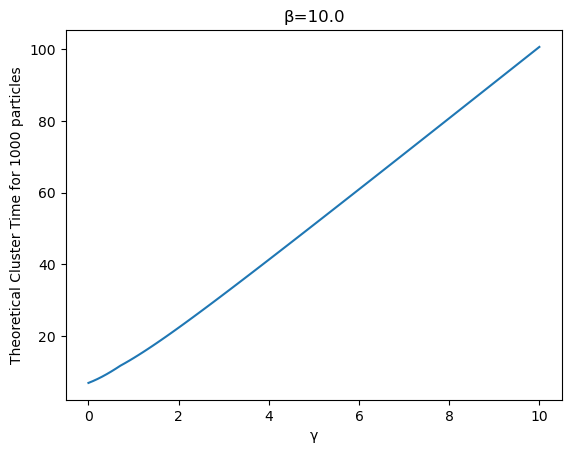

In [48]:
plt.plot(γ_list,np.log(1000)/(2*spectral_radius[-1,:]))
#plt.xscale('log')
#plt.yscale('log')
plt.title('β='+str(β_list[-1]))
plt.xlabel('γ')
plt.ylabel('Theoretical Cluster Time for 1000 particles')

Text(0, 0.5, 'Frequency of phase transition')

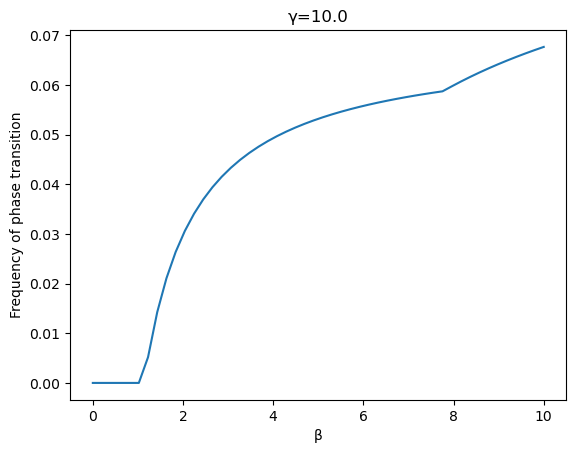

In [26]:
plt.plot(β_list,spectral_radius[:,2])
#plt.xscale('log')
#plt.yscale('log')
plt.title('γ='+str(γ_list[-1]))
plt.xlabel('β')
plt.ylabel('Frequency of phase transition')

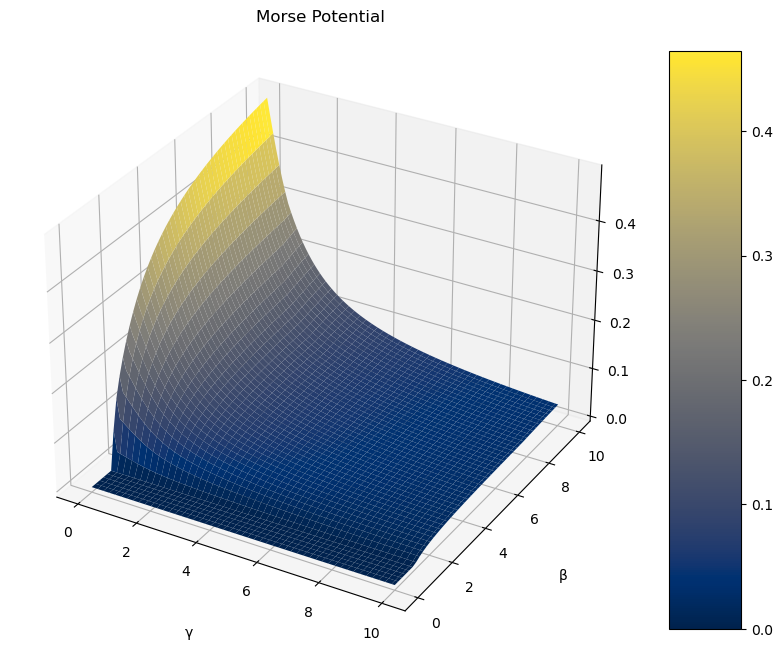

In [50]:
#zlim = 0.1
fig = plt.figure(figsize =(10,15))
ax = plt.axes(projection ='3d')

X, Y = np.meshgrid(γ_list,β_list)

# Creating plot
surf = ax.plot_surface(X, Y, spectral_radius, cmap = plt.cm.cividis)



# Set axes label
ax.set_xlabel('γ', labelpad=20)
ax.set_ylabel('β', labelpad=20)
ax.set_zlabel('$k_{max}$', labelpad=20)
#ax.axes.set_zlim3d(bottom=0, top=zlim)
ax.set_title('Morse Potential')

fig.colorbar(surf, shrink=0.5, aspect=8)

plt.show()